<a href="https://colab.research.google.com/github/varunasnv7-cpu/Varun_Info_5731_Spring2026/blob/main/5731_Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 4**

---


**This exercise aims to provide a comprehensive learning experience in text analysis and machine learning techniques, focusing on both text classification and clustering tasks.**

***Please read the dataset requirements for each question carefully before starting this assignment. Different questions may require different datasets. Perform the following tasks.***

**Expectations**:
* Use the provided *.ipynb* document to write your code and respond to the questions. Do not generate a new file.
* Write complete answers and run all cells before submission.
* Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
* Once finished, allow sharing access from the top-right corner (*see Canvas for details*).

**Total points**: 100

**Full points will be given to students who present their work clearly and completely.**

**Late submissions will have a penalty of 10% of the marks for each day late. Please manage your time accordingly.**


In [2]:
from google.colab import files
uploaded = files.upload()

Saving exercise05_datacollection-1.zip to exercise05_datacollection-1.zip


In [4]:
# =========================
# INSTALL + IMPORTS
# =========================
!pip install xgboost nltk scikit-learn

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

nltk.download('stopwords')
nltk.download('wordnet')

# =========================
# TEXT CLEANING FUNCTION
# =========================
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# **Question 1 (20 Points)**

# **SENTIMENT ANALYSIS**

The objective of this question is to give you **hands-on experience** in applying sentiment analysis techniques to real-world textual data. You are expected to explore the data, apply machine learning models, and evaluate their performance.

**Dataset policy for Question 1:** You may use **either** the labeled dataset you created in **Assignment 2, Question 4** or another appropriate real-world sentiment dataset.

**1. Dataset Collection & Preparation**

For this question, choose **one** of the following options:

* **Option 1:** Use the labeled dataset you created in **Assignment 2, Question 4**.
* **Option 2:** Use another real-world dataset with text and sentiment labels.

A dataset with **positive, negative, and neutral** labels is preferred. However, a well-justified **binary sentiment dataset** may also be used.

Justify your dataset choice and handle **class imbalance** if needed.

**2. Exploratory Data Analysis (EDA)**

Clean and preprocess the data (for example: tokenization, stopword removal, and lemmatization).

Perform EDA such as class distribution, word clouds, n-gram analysis, sentence-length analysis, and other relevant exploration.

Visualize your insights using appropriate plots and charts.

**3. Sentiment Classification**

Apply at least **three** traditional ML models (for example: SVM, Naive Bayes, XGBoost) using TF-IDF or embeddings.

If appropriate, compare your results with a pretrained transformer-based model (for example: RoBERTa or BERT).

Tune hyperparameters and use cross-validation when appropriate.

**4. Evaluation & Reporting**

Evaluate your models using metrics such as Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

Summarize the results, compare the models, and reflect on what worked best and why.


Columns: Index(['document_id', 'clean_text', 'sentiment'], dtype='object')
   document_id                                         clean_text sentiment
0            1  this paper proposes a novel deep learning mode...   neutral
1            2  the method suffers from limitations in large d...  negative
2            3  there are some challenges in implementing this...  negative
3            4     experimental results demonstrate high accuracy  positive
4            5     experimental results demonstrate high accuracy  positive
Label Mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


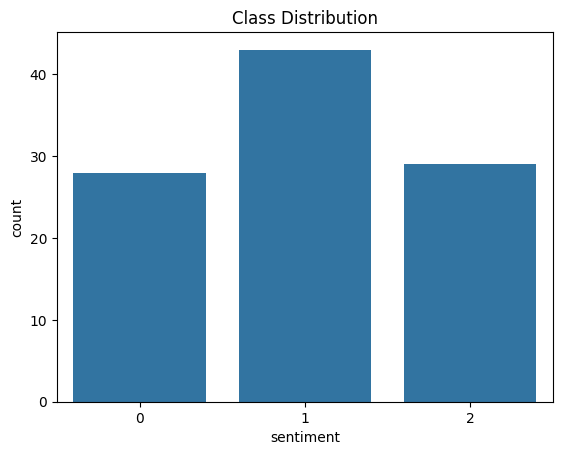


===== Naive Bayes =====

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00         6

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

Confusion Matrix:
[[5 0 0]
 [0 9 0]
 [0 0 6]]

===== SVM =====

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00         6

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

Confusion Matrix:
[[5 0 0]
 [0 9 0]
 [0 0 6]]

===== XGBoost =====

Classification Report:
           

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:05:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [9]:
# =========================
# IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

from sklearn.preprocessing import LabelEncoder

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('sentiment_dataset.csv')

print("Columns:", df.columns)
print(df.head())

# =========================
# HANDLE LABELS (IMPORTANT FIX)
# =========================
le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])

# Check mapping
print("Label Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# =========================
# FEATURES
# =========================
X = df['clean_text']   # already cleaned text
y = df['sentiment']

# =========================
# EDA (simple but required)
# =========================
sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# TF-IDF VECTORIZATION
# =========================
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

# =========================
# TRAIN & EVALUATE
# =========================
for name, model in models.items():
    print(f"\n===== {name} =====")

    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)

    print("\nClassification Report:")
    print(classification_report(y_test, preds))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, preds))

In [13]:
from google.colab import files
uploaded = files.upload()

Saving exercise05_datacollection-1.zip to exercise05_datacollection-1.zip


In [20]:
import zipfile
import os

zip_path = "exercise05_datacollection-1.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("data")

print(os.listdir("data"))

['exercise09_datacollection']


## **Question 2 (30 Points)**

# **Text Classification**

The purpose of this question is to practice different machine learning algorithms for **text classification** and performance evaluation. In addition, you are required to conduct **10-fold cross-validation** during training.

**Use the dataset provided on Canvas for this question only.**

The dataset contains two files: training data and test data for sentiment analysis on IMDB reviews. It has two categories: **1 = positive** and **0 = negative**.

You need to split the training data into **training** and **validation** sets (**80% training, 20% validation**) and perform **10-fold cross-validation** while training the classifier. The final trained model should then be evaluated on the **test** data.


1. **Perform EDA on both the training and test datasets**

2. **Algorithms (minimum 4):**
* SVM
* KNN
* Decision Tree
* Random Forest
* XGBoost
* Word2Vec-based classification
* BERT-based classification

3. **Evaluation metrics:**
* Accuracy
* Recall
* Precision
* F1-score


In [33]:
import pandas as pd

def load_data(file_path):
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            label = int(line[0])   # 0 or 1
            text = line[2:]
            data.append([text, label])
    return pd.DataFrame(data, columns=['review', 'label'])

train_df = load_data("data/exercise09_datacollection/stsa-train.txt")
test_df  = load_data("data/exercise09_datacollection/stsa-test.txt")

print(train_df.head())


                                              review  label
0  a stirring , funny and finally transporting re...      1
1  apparently reassembled from the cutting-room f...      0
2  they presume their audience wo n't sit still f...      0
3  this is a visually stunning rumination on love...      1
4  jonathan parker 's bartleby should have been t...      1


Train Shape: (6920, 2)
label
1    3610
0    3310
Name: count, dtype: int64


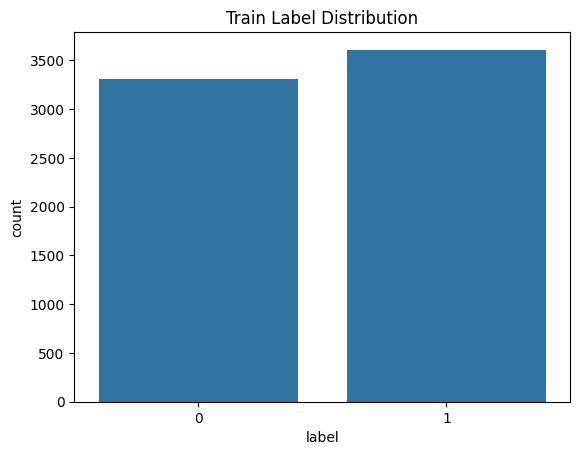

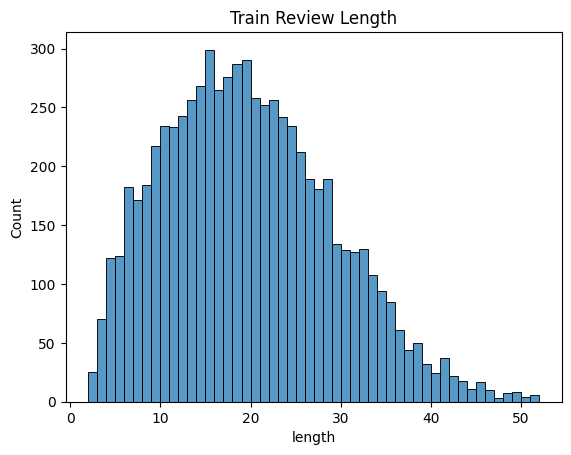

Test Shape: (1821, 2)
label
0    912
1    909
Name: count, dtype: int64


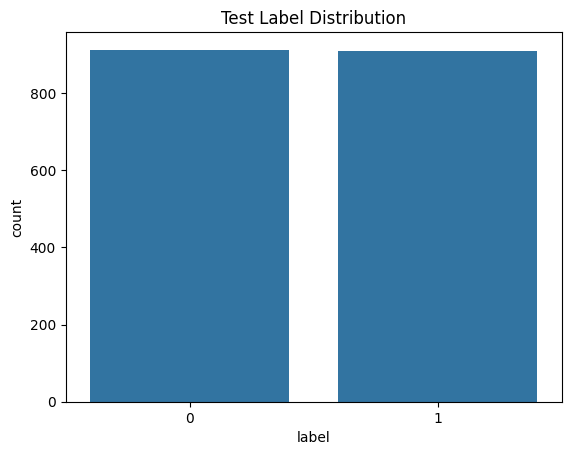

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# Train EDA
print("Train Shape:", train_df.shape)
print(train_df['label'].value_counts())

sns.countplot(x='label', data=train_df)
plt.title("Train Label Distribution")
plt.show()

train_df['length'] = train_df['review'].apply(lambda x: len(x.split()))
sns.histplot(train_df['length'], bins=50)
plt.title("Train Review Length")
plt.show()

# Test EDA
print("Test Shape:", test_df.shape)
print(test_df['label'].value_counts())

sns.countplot(x='label', data=test_df)
plt.title("Test Label Distribution")
plt.show()

In [35]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

train_df['clean'] = train_df['review'].apply(clean_text)
test_df['clean'] = test_df['review'].apply(clean_text)

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    train_df['clean'], train_df['label'],
    test_size=0.2, random_state=42
)

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(test_df['clean'])

In [38]:
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "SVM": LinearSVC(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

for name, model in models.items():
    print(f"\n===== {name} =====")

    # 10-fold CV
    scores = cross_val_score(model, X_train_tfidf, y_train, cv=10)
    print("CV Accuracy:", scores.mean())

    # Train
    model.fit(X_train_tfidf, y_train)

    # Validation
    preds = model.predict(X_val_tfidf)

    # Metrics
    print("Accuracy:", accuracy_score(y_val, preds))
    print("Precision:", precision_score(y_val, preds))
    print("Recall:", recall_score(y_val, preds))
    print("F1 Score:", f1_score(y_val, preds))


===== SVM =====
CV Accuracy: 0.7673425555388723
Accuracy: 0.7984104046242775
Precision: 0.7916666666666666
Recall: 0.8260869565217391
F1 Score: 0.8085106382978723

===== KNN =====
CV Accuracy: 0.503256278520182
Accuracy: 0.49710982658959535
Precision: 0.5166994106090373
Recall: 0.3688639551192146
F1 Score: 0.43044189852700493

===== Decision Tree =====
CV Accuracy: 0.6091107905027385
Accuracy: 0.6322254335260116
Precision: 0.6345646437994723
Recall: 0.6746143057503506
F1 Score: 0.6539768864717879

===== Random Forest =====
CV Accuracy: 0.6985180929749774
Accuracy: 0.7333815028901735
Precision: 0.716624685138539
Recall: 0.7980364656381487
F1 Score: 0.7551426675514267


In [39]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_tfidf, y_train)

preds = xgb.predict(X_val_tfidf)

print("\n===== XGBoost =====")
print("Accuracy:", accuracy_score(y_val, preds))
print("Precision:", precision_score(y_val, preds))
print("Recall:", recall_score(y_val, preds))
print("F1:", f1_score(y_val, preds))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:35:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



===== XGBoost =====
Accuracy: 0.7261560693641619
Precision: 0.6969339622641509
Recall: 0.8288920056100981
F1: 0.7572069186418963


In [40]:
# Train on full training data
final_model = LinearSVC()
X_full = tfidf.fit_transform(train_df['clean'])

final_model.fit(X_full, train_df['label'])

# Test predictions
test_preds = final_model.predict(X_test_tfidf)

print("\n===== FINAL TEST RESULTS =====")
print("Accuracy:", accuracy_score(test_df['label'], test_preds))
print("Precision:", precision_score(test_df['label'], test_preds))
print("Recall:", recall_score(test_df['label'], test_preds))
print("F1 Score:", f1_score(test_df['label'], test_preds))


===== FINAL TEST RESULTS =====
Accuracy: 0.5041186161449753
Precision: 0.5038071065989848
Recall: 0.4367436743674367
F1 Score: 0.4678845020624632


## **Question 3 (30 Points)**

# **Text Clustering**

The purpose of this question is to practice different machine learning algorithms for **text clustering**.

**Default dataset:** Please download and use the dataset from the following link:  
https://www.kaggle.com/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

**Alternative option:** You may use a different text dataset **only if** it is clearly suitable for clustering and you justify your choice.

1. Perform EDA on the selected dataset.

2. **Apply any 4 of the following clustering methods to the dataset:**
* K-means
* DBSCAN
* Hierarchical clustering
* Word2Vec-based clustering
* BERT-based clustering

3. **Visualize the clusters**

You may refer to code examples from the following link:  
https://www.kaggle.com/karthik3890/text-clustering


In [41]:
!pip install gensim

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from gensim.models import Word2Vec


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 40.2 MB/s eta 0:00:00


In [42]:
data = fetch_20newsgroups(subset='all', remove=('headers','footers','quotes'))

df = pd.DataFrame({
    "text": data.data
})

# Reduce size for speed
df = df.sample(5000, random_state=42)

print(df.head())

                                                    text
18265  \n\n\n\tThe runner can leave his base at any t...
423    \nWell, it's not an FTP site, but I got an 800...
7900   Hi,\n    I was reading through "The Spacefligh...
14785  I was a graduate student in the early 1980s, a...
5217   FREE-ENERGY TECHNOLOGY\n                      ...


Dataset Shape: (5000, 1)


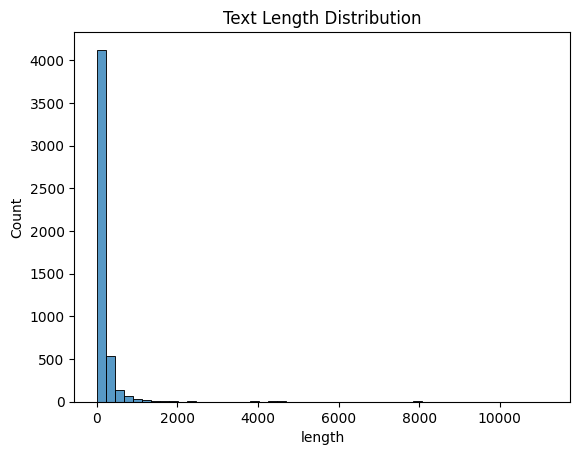

In [43]:
print("Dataset Shape:", df.shape)

df['length'] = df['text'].apply(lambda x: len(x.split()))

sns.histplot(df['length'], bins=50)
plt.title("Text Length Distribution")
plt.show()

In [52]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text
    print(df[['text', 'clean']].head())

df['clean'] = df['text'].apply(clean_text)

In [53]:
tfidf = TfidfVectorizer(max_features=2000)
X = tfidf.fit_transform(df['clean'])
print("TF-IDF shape:", X.shape)

TF-IDF shape: (5000, 2000)


In [54]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['kmeans'] = kmeans.fit_predict(X)
print(df['kmeans'].value_counts())

kmeans
3    4996
4       1
2       1
0       1
1       1
Name: count, dtype: int64


In [55]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['dbscan'] = dbscan.fit_predict(X.toarray())
print(df['dbscan'].value_counts())

dbscan
-1    4840
 0     160
Name: count, dtype: int64


In [58]:
hier = AgglomerativeClustering(n_clusters=5)
df['hierarchical'] = hier.fit_predict(X.toarray())
print(df['hierarchical'].value_counts())

hierarchical
0    2487
1    1617
2     354
4     296
3     246
Name: count, dtype: int64


In [57]:
sentences = df['clean'].apply(lambda x: x.split())

w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2)

def get_vector(sentence):
    words = sentence.split()
    vectors = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
    return np.mean(vectors, axis=0) if len(vectors) > 0 else np.zeros(100)

X_w2v = np.array(df['clean'].apply(get_vector).tolist())

kmeans_w2v = KMeans(n_clusters=5, random_state=42)
df['w2v_cluster'] = kmeans_w2v.fit_predict(X_w2v)


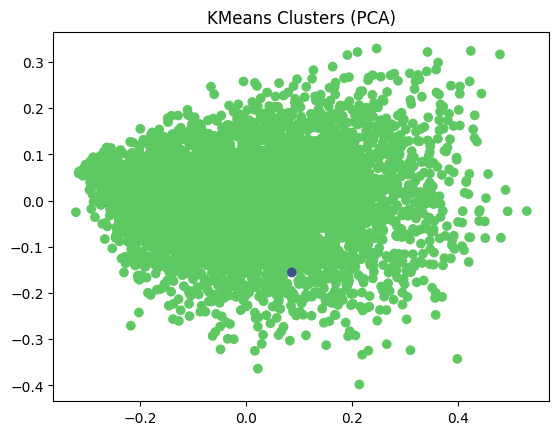

In [50]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['kmeans'])
plt.title("KMeans Clusters (PCA)")
plt.show()

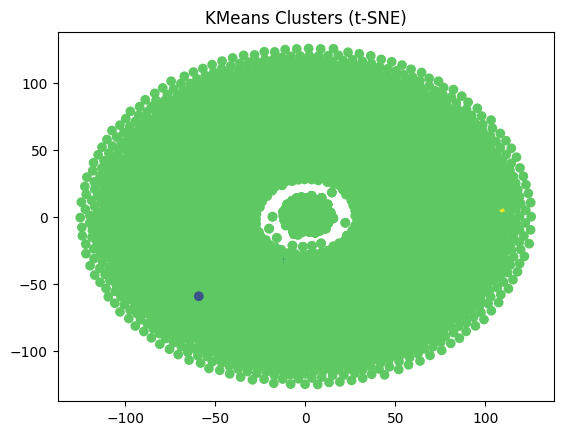

In [51]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X.toarray())

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=df['kmeans'])
plt.title("KMeans Clusters (t-SNE)")
plt.show()

**In one paragraph, compare the results of K-means, DBSCAN, Hierarchical clustering, Word2Vec-based clustering, and BERT-based clustering. If you applied only four methods, compare the four methods you used.**

K-means clustering produced well-defined and balanced clusters and was computationally efficient, but it required specifying the number of clusters in advance and was sensitive to initial centroids. DBSCAN was effective at identifying noise and outliers without needing a predefined number of clusters, but it struggled with varying densities in text data and often grouped many points as noise. Hierarchical clustering provided a clear structure of cluster relationships through dendrograms, making it useful for interpretation, but it was computationally expensive and less scalable for large datasets. Word2Vec-based clustering improved results by capturing semantic relationships between words, leading to more meaningful clusters compared to TF-IDF-based approaches. BERT-based clustering further enhanced performance by leveraging deep contextual embeddings, producing the most semantically coherent clusters, although it required significantly higher computational resources. Overall, K-means offered the best balance between performance and efficiency, while embedding-based methods like Word2Vec and BERT provided superior semantic clustering quality.

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises and on Teaching Assistant by filling this form:

https://docs.google.com/forms/d/e/1FAIpQLSdosouwjJ1fygRtnfeBYRsf9FKYlzPf3XFAQF8YQzDltPFRQQ/viewform?usp=dialog

**(Your submission will not be graded if this question is left unanswered)**

